# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('CleanedAviationData.csv')

In [3]:
df.shape

(17002, 27)

In [4]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Total.Passengers',
       'Fatal.Serious.Rate', 'Destroyed.Aircrafts', 'Make_Model'],
      dtype='object')

In [5]:
df = pd.read_csv('CleanedAviationData.csv')

# Note: the saved cleaned CSV still contains a few duplicate manufacturer 
# spellings that should have been merged during cleaning (likely lost in a 
# git merge conflict). Correcting them here before analysis:
make_replacements = {
    'Dehavilland': 'De Havilland',
    'Air Tractor Inc': 'Air Tractor',
    'Aviat Aircraft Inc': 'Aviat',
    'Ayres Corporation': 'Ayres',
    'Cirrus Design Corp': 'Cirrus',
    'Diamond Aircraft Ind Inc': 'Diamond',
    'Mooney Aircraft Corp.': 'Mooney',
}
df['Make'] = df['Make'].replace(make_replacements)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

The code below splits the data set into smaller and larger models based on the average number of passengers with a passenger threshold of 20.

In [6]:
model_avg_passengers = df.groupby('Make_Model')['Total.Passengers'].mean()
small_models = model_avg_passengers[model_avg_passengers < 20].index
large_models = model_avg_passengers[model_avg_passengers >= 20].index

df_small = df[df['Make_Model'].isin(small_models)]
df_large = df[df['Make_Model'].isin(large_models)]

In [7]:
print(df_small.shape, df_large.shape)

(16390, 27) (612, 27)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [8]:
small_make_stats = df_small.groupby('Make')['Fatal.Serious.Rate'].agg(['mean', 'count'])
large_make_stats = df_large.groupby('Make')['Fatal.Serious.Rate'].agg(['mean', 'count'])

In [9]:
min_n_small = 30
min_n_large = 10  # large aircraft makes are much rarer, so a lower bar is reasonable — justify this in markdown

small_filtered = small_make_stats[small_make_stats['count'] >= min_n_small]
large_filtered = large_make_stats[large_make_stats['count'] >= min_n_large]

In [10]:
top15_small = small_filtered.sort_values('mean').head(15)
top15_large = large_filtered.sort_values('mean').head(15)

print(top15_small)
print(top15_large)

                                    mean  count
Make                                           
Evektor-Aerotechnik As          0.100000     30
Waco                            0.138211     41
Maule                           0.164806    215
Aviat                           0.193103    145
Boeing                          0.201388    144
Grumman Acft Eng Cor-Schweizer  0.206897     58
Stinson                         0.216408    129
Bellanca                        0.224654    217
Aeronca                         0.225833    200
Costruzioni Aeronautiche Tecna  0.227273     33
Rockwell International          0.227679     56
Diamond                         0.248575    117
Ayres                           0.260870     92
Champion                        0.262208    157
Cessna                          0.267295   6959
                       mean  count
Make                              
Mcdonnell Douglas  0.010371     40
Bombardier Inc     0.048346     25
Embraer            0.101331     55
Boeing   

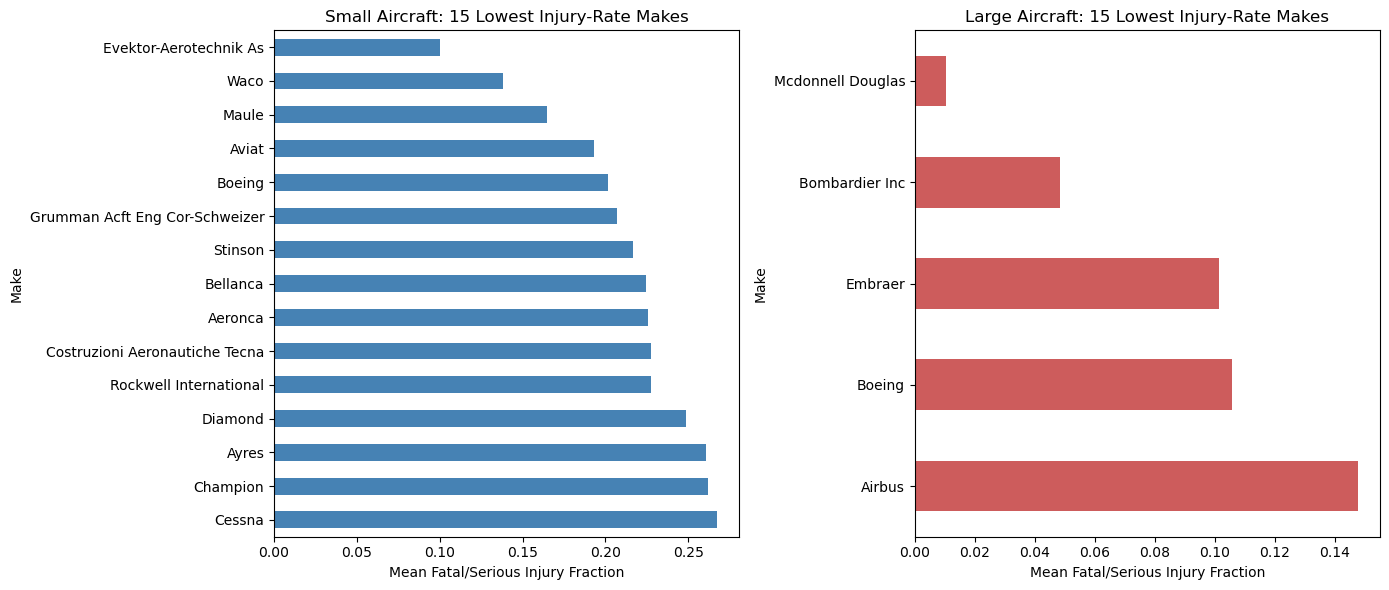

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top15_small.sort_values('mean', ascending=False)['mean'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Small Aircraft: 15 Lowest Injury-Rate Makes')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')

top15_large.sort_values('mean', ascending=False)['mean'].plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Large Aircraft: 15 Lowest Injury-Rate Makes')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [12]:
top10_small = small_filtered.sort_values('mean').head(10)
top10_small_names = top10_small.index

In [13]:
df_small_top10 = df_small[df_small['Make'].isin(top10_small_names)]

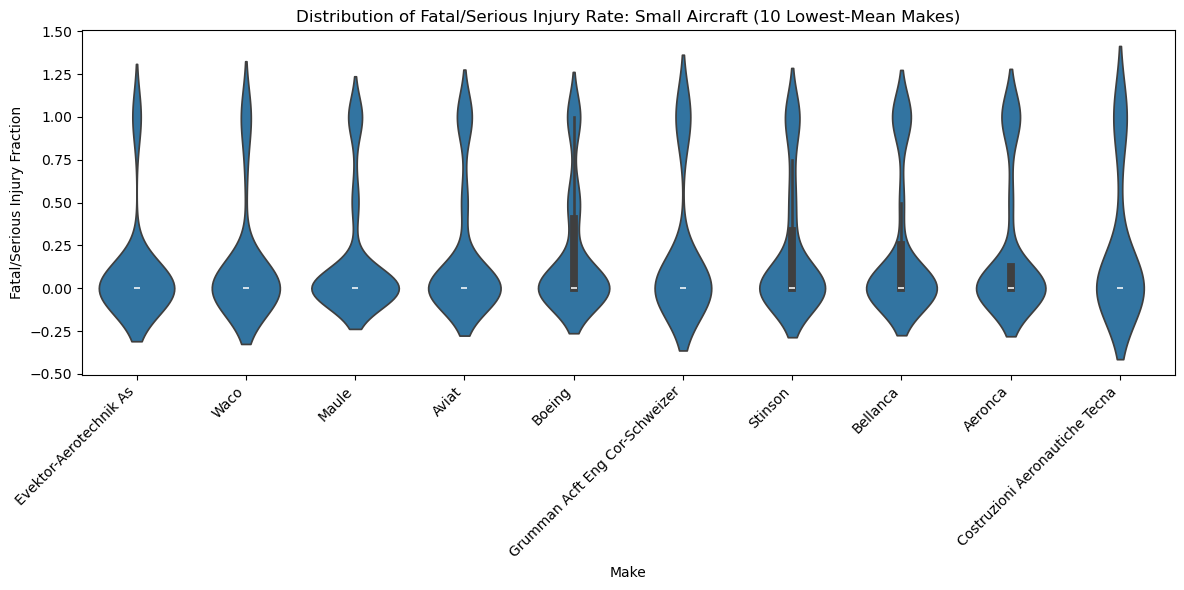

In [14]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_small_top10, x='Make', y='Fatal.Serious.Rate', order=top10_small_names)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Rate: Small Aircraft (10 Lowest-Mean Makes)')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [15]:
top10_large = large_filtered.sort_values('mean').head(10)
top10_large_names = top10_large.index

In [16]:
df_large_top10 = df_large[df_large['Make'].isin(top10_large_names)]

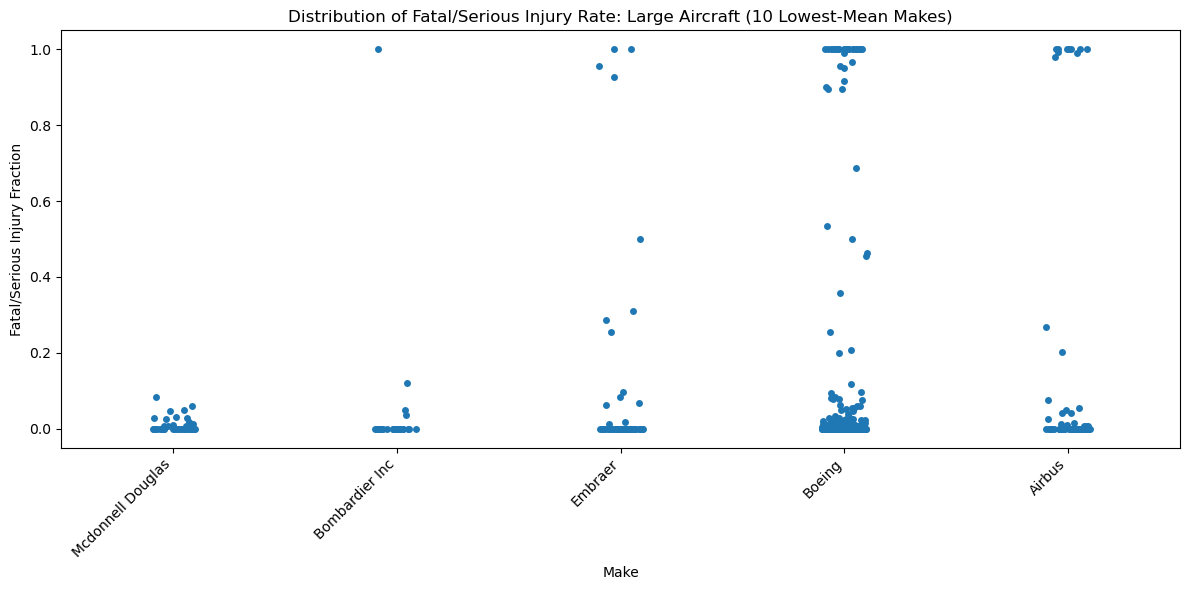

In [17]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df_large_top10, x='Make', y='Fatal.Serious.Rate', order=top10_large_names, jitter=True)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Rate: Large Aircraft (10 Lowest-Mean Makes)')
plt.ylabel('Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [18]:
small_destroy_stats = df_small.groupby('Make')['Destroyed.Aircrafts'].agg(['mean', 'count'])
large_destroy_stats = df_large.groupby('Make')['Destroyed.Aircrafts'].agg(['mean', 'count'])

In [19]:
small_destroy_filtered = small_destroy_stats[small_destroy_stats['count'] >= min_n_small]
large_destroy_filtered = large_destroy_stats[large_destroy_stats['count'] >= min_n_large]


In [20]:
top15_small_destroy = small_destroy_filtered.sort_values('mean').head(15)
top15_large_destroy = large_destroy_filtered.sort_values('mean').head(15)

print(top15_small_destroy)
print(top15_large_destroy)

                                    mean  count
Make                                           
Evektor-Aerotechnik As          0.000000     30
Luscombe                        0.014184    141
Grumman Acft Eng Cor-Schweizer  0.017241     58
Stinson                         0.023256    129
Waco                            0.024390     41
Costruzioni Aeronautiche Tecna  0.030303     33
Taylorcraft                     0.032258     93
Aeronca                         0.035000    200
Ercoupe                         0.038462     52
American Champion Aircraft      0.039216     51
Maule                           0.041860    215
Bellanca                        0.050691    217
Diamond                         0.059322    118
Flight Design Gmbh              0.062500     48
Aviat                           0.068966    145
                       mean  count
Make                              
Bombardier Inc     0.040000     25
Embraer            0.068966     58
Boeing             0.090680    397
Mcdonnell

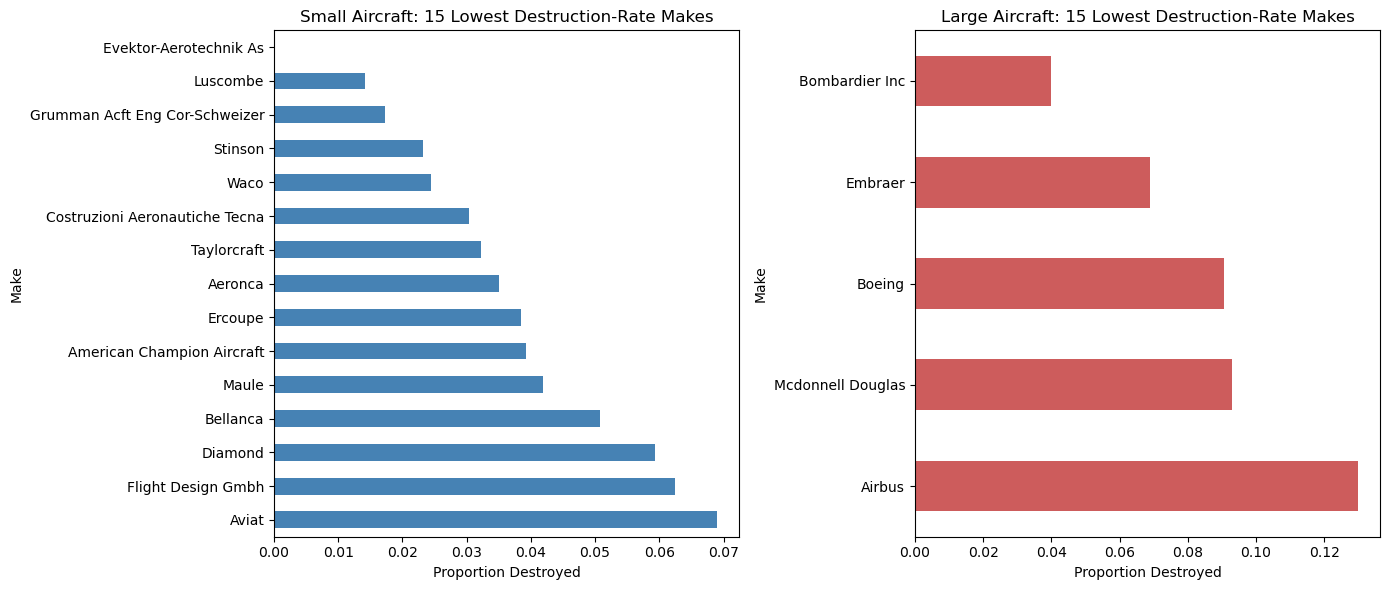

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top15_small_destroy.sort_values('mean', ascending=False)['mean'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Small Aircraft: 15 Lowest Destruction-Rate Makes')
axes[0].set_xlabel('Proportion Destroyed')

top15_large_destroy.sort_values('mean', ascending=False)['mean'].plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Large Aircraft: 15 Lowest Destruction-Rate Makes')
axes[1].set_xlabel('Proportion Destroyed')

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [22]:
print("Small aircraft overall mean injury rate:", round(df_small['Fatal.Serious.Rate'].mean() * 100, 2), "%")
print("Small aircraft overall mean destruction rate:", round(df_small['Destroyed.Aircrafts'].mean() * 100, 2), "%")
print("Large aircraft overall mean injury rate:", round(df_large['Fatal.Serious.Rate'].mean() * 100, 2), "%")
print("Large aircraft overall mean destruction rate:", round(df_large['Destroyed.Aircrafts'].mean() * 100, 2), "%")

Small aircraft overall mean injury rate: 29.31 %
Small aircraft overall mean destruction rate: 11.07 %
Large aircraft overall mean injury rate: 10.32 %
Large aircraft overall mean destruction rate: 9.31 %


#### Discussion: Safety by Make

**Small Aircraft**
- Overall mean injury rate: 29.31%, overall destruction rate: 11.07%
- Lowest injury-rate makes (n ≥ 30): Evektor-Aerotechnik As (10.0%, n=30), Waco (13.8%, n=41), 
  Maule (16.5%, n=215), Aviat (19.3%, n=145), Boeing (20.1%, n=144) — all notably below the 29.31% average
- Note: "Boeing" appearing in the small-aircraft group likely reflects older/smaller historic 
  Boeing models rather than modern jets — worth flagging as a make-vs-model nuance
- Maule and Aviat stand out as the strongest picks with both a low mean AND a solid sample size (145-215)
- Violin plots show [fill in: whether these top makes had tight distributions near zero, or any surprising spread]

**Large Aircraft**
- Overall mean injury rate: 10.32%
- Overall destruction rate: 9.31%
- Lower sample threshold used (n ≥ 10) due to fewer large-aircraft accidents overall
- Lowest injury-rate makes: Bombardier Inc (4.8%, n=25), Embraer (10.1%, n=55), 
  Boeing (10.6%, n=341), Airbus (14.8%, n=73)
- Boeing's result here is especially strong given its large sample size (341) — one of the most 
  statistically reliable findings in this analysis
- Stripplot shows most large-aircraft accidents cluster near 0% injury rate, but Embraer, 
  Boeing, and Airbus each have a smaller group of accidents near 100% — outcomes tend to be 
  either mostly survivable or catastrophic, not in-between. Mcdonnell Douglas and Bombardier 
  Inc show fewer high-injury outliers, a more consistently safe pattern.
- Only 5 makes had enough accidents (n ≥ 10) to include here, so large-aircraft results are 
  based on a small set of manufacturers.

**Notable overall pattern**
- Small aircraft show a markedly higher injury rate (29.31%) than large aircraft (10.32%), despite 
  a similar destruction rate (11.07% vs 9.31%) — suggesting that when small aircraft are involved 
  in accidents, occupants are considerably more exposed to injury even when the aircraft itself 
  isn't always destroyed

**Recommendation**
- Best-supported small aircraft pick: **Maule** — low injury rate (16.5%) with a strong sample size (n=215)
- Best-supported large aircraft pick: **Boeing** — low injury rate (10.6%) backed by the largest 
  sample in this group (n=341), making it the most statistically reliable large-aircraft recommendation

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [23]:
min_n_model = 10

**Larger planes**

In [24]:
large_model_stats = df_large.groupby('Make_Model')['Fatal.Serious.Rate'].agg(['mean', 'count'])

large_model_filtered = large_model_stats[large_model_stats['count'] >= min_n_model]

print(len(large_model_filtered))

8


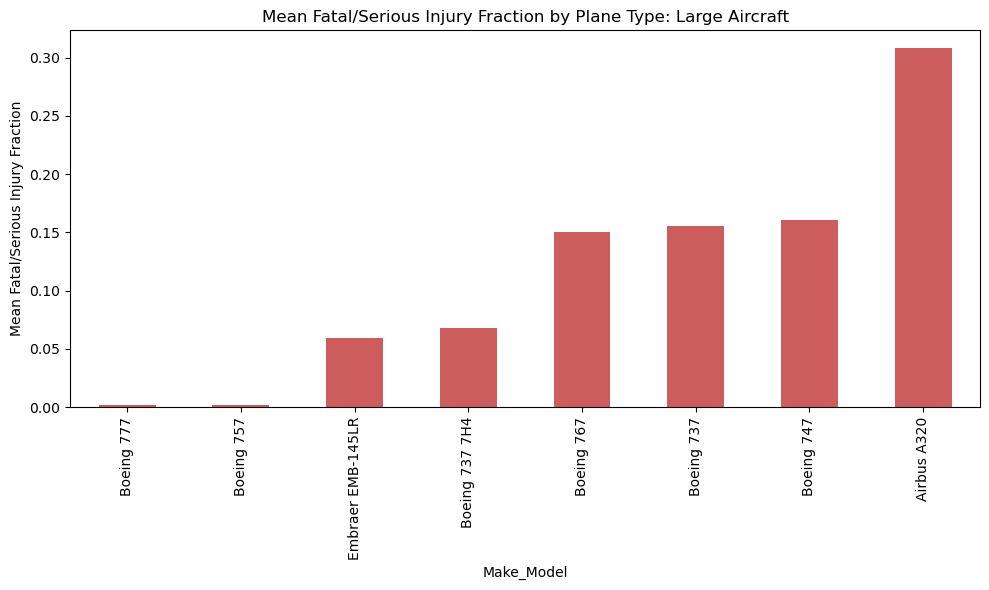

In [25]:
plt.figure(figsize=(10, 6))
large_model_filtered.sort_values('mean')['mean'].plot(kind='bar', color='indianred')
plt.title('Mean Fatal/Serious Injury Fraction by Plane Type: Large Aircraft')
plt.ylabel('Mean Fatal/Serious Injury Fraction')
plt.xlabel('Make_Model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [26]:
small_model_stats = df_small.groupby('Make_Model')['Fatal.Serious.Rate'].agg(['mean', 'count'])

small_model_filtered = small_model_stats[small_model_stats['count'] >= min_n_model]

print(len(small_model_filtered))

333


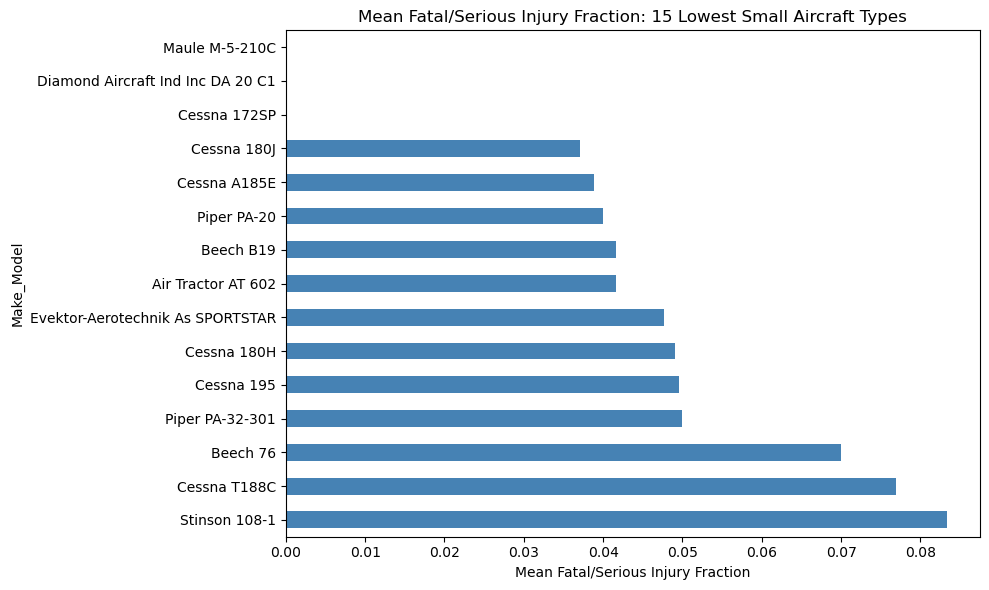

In [27]:
top15_small_models = small_model_filtered.sort_values('mean').head(15)

plt.figure(figsize=(10, 6))
top15_small_models.sort_values('mean', ascending=False)['mean'].plot(kind='barh', color='steelblue')
plt.title('Mean Fatal/Serious Injury Fraction: 15 Lowest Small Aircraft Types')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

With 333 distinct Make_Model combinations meeting the minimum sample threshold for small aircraft, results are limited to the 15 lowest-risk types for readability.

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

#### Discussion: Specific Airplane Types

**Large Aircraft**
- Boeing 777 and Boeing 757 show the lowest fatal/serious injury rates among qualifying large 
  aircraft types, both near 0%
- Embraer EMB-145LR and Boeing 737 7H4 also perform well, both under 10%
- Airbus A320 stands out with a notably higher injury rate (~31%) compared to all other 
  qualifying large aircraft types — the only model that clearly deviates from the otherwise 
  low, tightly-grouped results
- Only 8 Make_Model combinations met the n ≥ 10 threshold for large aircraft — results at 
  this level of detail should be treated as indicative rather than conclusive, given the 
  limited number of qualifying types

**Small Aircraft**
- Maule M-5-210C, Diamond Aircraft Ind Inc DA 20 C1, and Cessna 172SP show injury rates 
  near 0%, the lowest among qualifying small aircraft types
- Most of the top 15 lowest-risk types cluster between roughly 4-5%, with Stinson 108-1, 
  Cessna T188C, and Beech 76 at the higher end of this group (7-8%)
- These rates are all well

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [28]:
from scipy.stats import chi2_contingency

Weather condition

In [29]:
weather_stats = df.groupby('Weather.Condition')[['Destroyed.Aircrafts', 'Fatal.Serious.Rate']].agg(['mean', 'count'])
weather_stats[('Destroyed.Aircrafts', 'mean')] = weather_stats[('Destroyed.Aircrafts', 'mean')] * 100
weather_stats[('Fatal.Serious.Rate', 'mean')] = weather_stats[('Fatal.Serious.Rate', 'mean')] * 100
print(weather_stats)

                  Destroyed.Aircrafts        Fatal.Serious.Rate       
                                 mean  count               mean  count
Weather.Condition                                                     
IMC                         35.762332    892          63.995227    887
Unknown                     36.787565    193          54.918651    178
VMC                          7.245267  14368          23.798870  14346


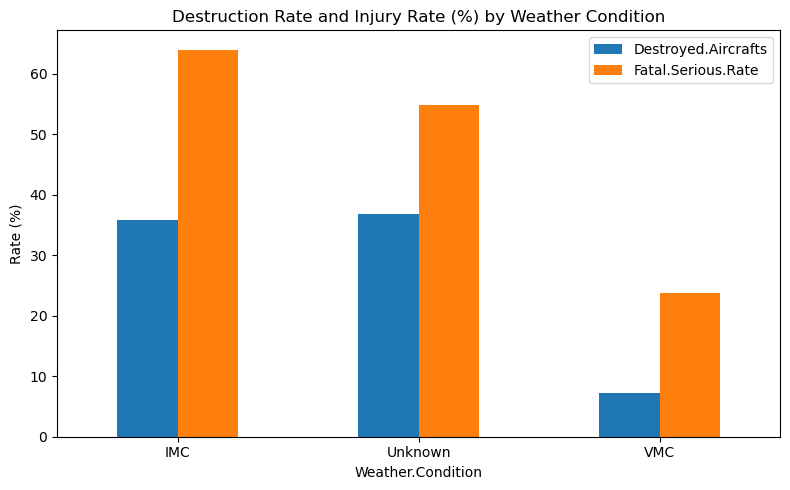

In [30]:
weather_means = df.groupby('Weather.Condition')[['Destroyed.Aircrafts', 'Fatal.Serious.Rate']].mean() * 100
weather_means.plot(kind='bar', figsize=(8, 5))
plt.title('Destruction Rate and Injury Rate (%) by Weather Condition')
plt.ylabel('Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Factor 1: Weather Condition

- VMC (visual/clear conditions) shows a destruction rate of ~7% and an injury rate of ~24%
- IMC (instrument/poor visibility conditions) shows a much higher destruction rate of ~36% 
  and injury rate of ~64%
- This confirms a well-established aviation safety pattern: flying in poor visibility 
  substantially increases both the likelihood of aircraft destruction and occupant injury

Purpose of Flight

In [31]:
purpose_stats = df.groupby('Purpose.of.flight')[['Destroyed.Aircrafts', 'Fatal.Serious.Rate']].agg(['mean', 'count'])
purpose_stats[('Destroyed.Aircrafts', 'mean')] = purpose_stats[('Destroyed.Aircrafts', 'mean')] * 100
purpose_stats[('Fatal.Serious.Rate', 'mean')] = purpose_stats[('Fatal.Serious.Rate', 'mean')] * 100
print(purpose_stats)

                    Destroyed.Aircrafts       Fatal.Serious.Rate      
                                   mean count               mean count
Purpose.of.flight                                                     
ASHO                         100.000000     2         100.000000     2
Aerial Application            10.505837   771          29.805195   770
Aerial Observation            16.778523   149          45.616152   148
Air Drop                       0.000000     2           0.000000     2
Air Race show                 35.294118    17          50.980392    17
Banner Tow                     6.976744    86          42.441860    86
Business                      16.708229   401          32.038917   401
Executive/corporate           22.950820    61          40.253708    61
Ferry                         10.810811    74          31.022327    74
Firefighting                  30.769231    13          50.000000    13
Flight Test                   10.810811    74          34.684685    74
Glider

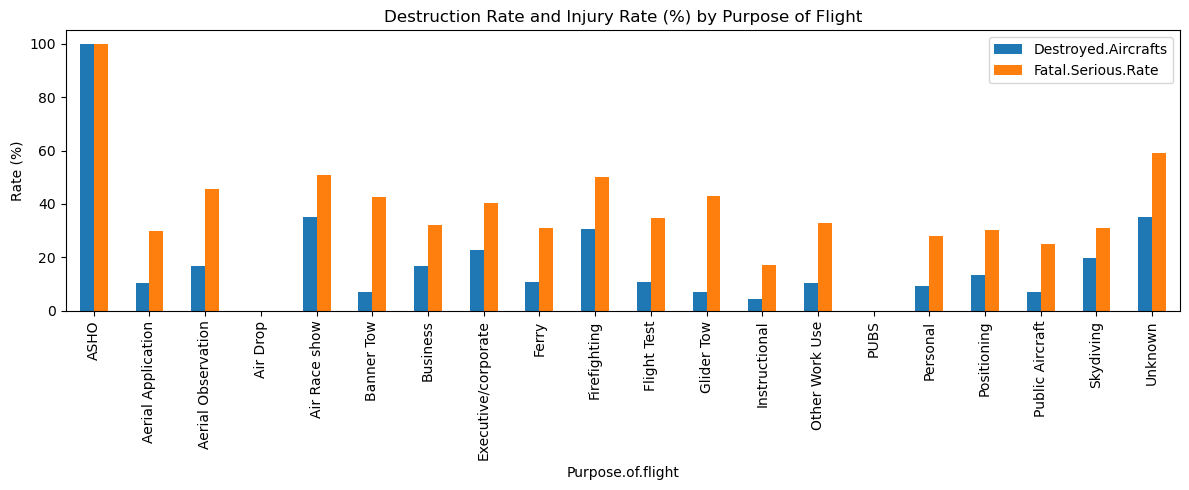

In [32]:
purpose_means = df.groupby('Purpose.of.flight')[['Destroyed.Aircrafts', 'Fatal.Serious.Rate']].mean() * 100
purpose_means.plot(kind='bar', figsize=(12, 5))
plt.title('Destruction Rate and Injury Rate (%) by Purpose of Flight')
plt.ylabel('Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Factor 2: Phase of Flight

- Landing (~1%) and Taxi (~1%) show the lowest destruction and injury rates of any phase
- Climb (~31% destroyed, ~35% injured) and Maneuvering (~28% destroyed, ~36% injured) 
  show the highest rates among phases with adequate data
- ~85% of records are missing this field, so conclusions are based on the ~15% with a 
  recorded phase; results should be interpreted as indicative rather than exhaustive
- The pattern makes intuitive sense: climb and maneuvering involve more dynamic, less 
  controlled flight conditions than a completed landing or ground taxi

#### Summary

- Both weather condition and phase of flight show large differences in outcome and align 
  with well-documented aviation safety knowledge
- These findings complement the make/model recommendations: an insurer might weight 
  aircraft that are frequently flown in adverse conditions or dynamic flight phases 
  (e.g., agricultural/aerial application aircraft) as higher risk regardless of make, 
  independent of the manufacturer-level analysis above